In [5]:
#%pip install statsmodels

### First, import packages and set default plotting parameters

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from venn import venn
import seaborn as sns
from matplotlib.colors import LogNorm
import statsmodels.api as sm
from pathlib import Path

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'flywire_data').exists() and (candidate / 'input').exists():
            return candidate
    raise FileNotFoundError('Could not find the Giakoumas-et-al project root from the current working directory.')

def resolve_existing_path(*candidates: Path) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    checked = "\n".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(f"Could not find any of these data files:\n{checked}")

PROJECT_ROOT = find_project_root()
FLYWIRE_DIR = PROJECT_ROOT / 'flywire_data'
INPUT_DIR = PROJECT_ROOT / 'input'
CONNECTIONS_PATH = resolve_existing_path(
    FLYWIRE_DIR / 'connections.csv',
    FLYWIRE_DIR / 'connections.csv.gz',
    FLYWIRE_DIR / 'connections.csv.zip',
)
NEUROPIL_SYNAPSE_PATH = resolve_existing_path(
    FLYWIRE_DIR / 'neuropil_synapse_table.csv.gz',
    FLYWIRE_DIR / 'neuropil_synapse_table.csv',
)
CLASSIFICATION_PATH = resolve_existing_path(
    FLYWIRE_DIR / 'classification.csv.gz',
    FLYWIRE_DIR / 'classification.csv',
)
NEURONS_PATH = resolve_existing_path(
    FLYWIRE_DIR / 'neurons.csv.gz',
    FLYWIRE_DIR / 'neurons.csv',
)
FIG_7_DIR = PROJECT_ROOT / 'output' / 'figures' / 'fig_7'
FIG_7_DATA_DIR = FIG_7_DIR / 'data'

for path in (FIG_7_DIR, FIG_7_DATA_DIR):
    path.mkdir(parents=True, exist_ok=True)


In [7]:
# Set seaborn theme to white
sns.set_theme(style='white')

# set up matplotlib theme
andy_theme = {'axes.grid': False,
              'grid.linestyle': '--',
              'legend.framealpha': 1,
              'legend.facecolor': 'white',
              'legend.shadow': False,
              'legend.fontsize': 14,
              'legend.title_fontsize': 14,
              'font.sans-serif':'Helvetica',
              'xtick.labelsize': 12,
              'ytick.labelsize': 12,
              'axes.labelsize': 16,
              'axes.titlesize': 18,
              'figure.dpi': 300}
plt.rcParams.update(andy_theme)

#Uncomment next 2 lines if matplotlib can not find Helvetica font
#plt.rcParams['font.family'] = 'DeJavu Serif'
#plt.rcParams['font.sans-serif'] = ['Arial']

## 1. FIRST ORDER ANALYSES

### Load the datasets with neurons and connections.

* This script assumes that the **CSV** files (`.csv.gz`) and **aStN-SAs lists** (`_new.csv` files) are in the same folder as this notebook or script.
* These files include four CSVs containing manually curated  aStN-SAs lists and four connectome datasets from FlyWire:
  1. **`classification.csv.gz`**
  2. **`connections.csv.gz`**
  3. **`neuropil_synapse_table.csv.gz`**
  4. **`neurons.csv.gz`**
* **Axon lists** were curated manually as described in the paper.
* **Connectome datasets** were downloaded from the FlyWire website using **snapshot 783** (previous snapshot 630).
* We focus on putative sensory axons from the Drosophila **pharyngeal nerve** in this analysis.


In [8]:
# Connections dataset and additional data sets
connections = pd.read_csv(
    CONNECTIONS_PATH
)

neuropil_synapse = pd.read_csv(
    NEUROPIL_SYNAPSE_PATH
)[['root_id', 'input synapses', 'output synapses']]
neuropil_synapse.rename(
    columns={'input synapses': 'input_synapses', 'output synapses': 'output_synapses'},
    inplace=True
)

classification = pd.read_csv(
    CLASSIFICATION_PATH
)[['root_id', 'side']]
classification_other = pd.read_csv(
    CLASSIFICATION_PATH
)[['root_id', 'super_class', 'class', 'nerve']]

neurons = pd.read_csv(NEURONS_PATH)[['root_id', 'nt_type']]

neurons_data = pd.merge(
    neurons,
    pd.merge(classification, neuropil_synapse, on='root_id', how='outer'),
    on='root_id', how='outer'
)

# Load putative StN-SA lists (six sets)
set_1 = pd.read_csv(PROJECT_ROOT / 'input' / 'PhN' / 'set_1.csv')
set_2 = pd.read_csv(PROJECT_ROOT / 'input' / 'PhN' / 'set_2.csv')
set_3 = pd.read_csv(PROJECT_ROOT / 'input' / 'PhN' / 'set_3.csv')
set_4 = pd.read_csv(PROJECT_ROOT / 'input' / 'PhN' / 'set_4.csv')
set_5 = pd.read_csv(PROJECT_ROOT / 'input' / 'PhN' / 'set_5.csv')
set_6 = pd.read_csv(PROJECT_ROOT / 'input' / 'PhN' / 'set_6.csv')


In [9]:
#fig.show(renderer="browser")
#fig.write_html("sankey_diagram.html")

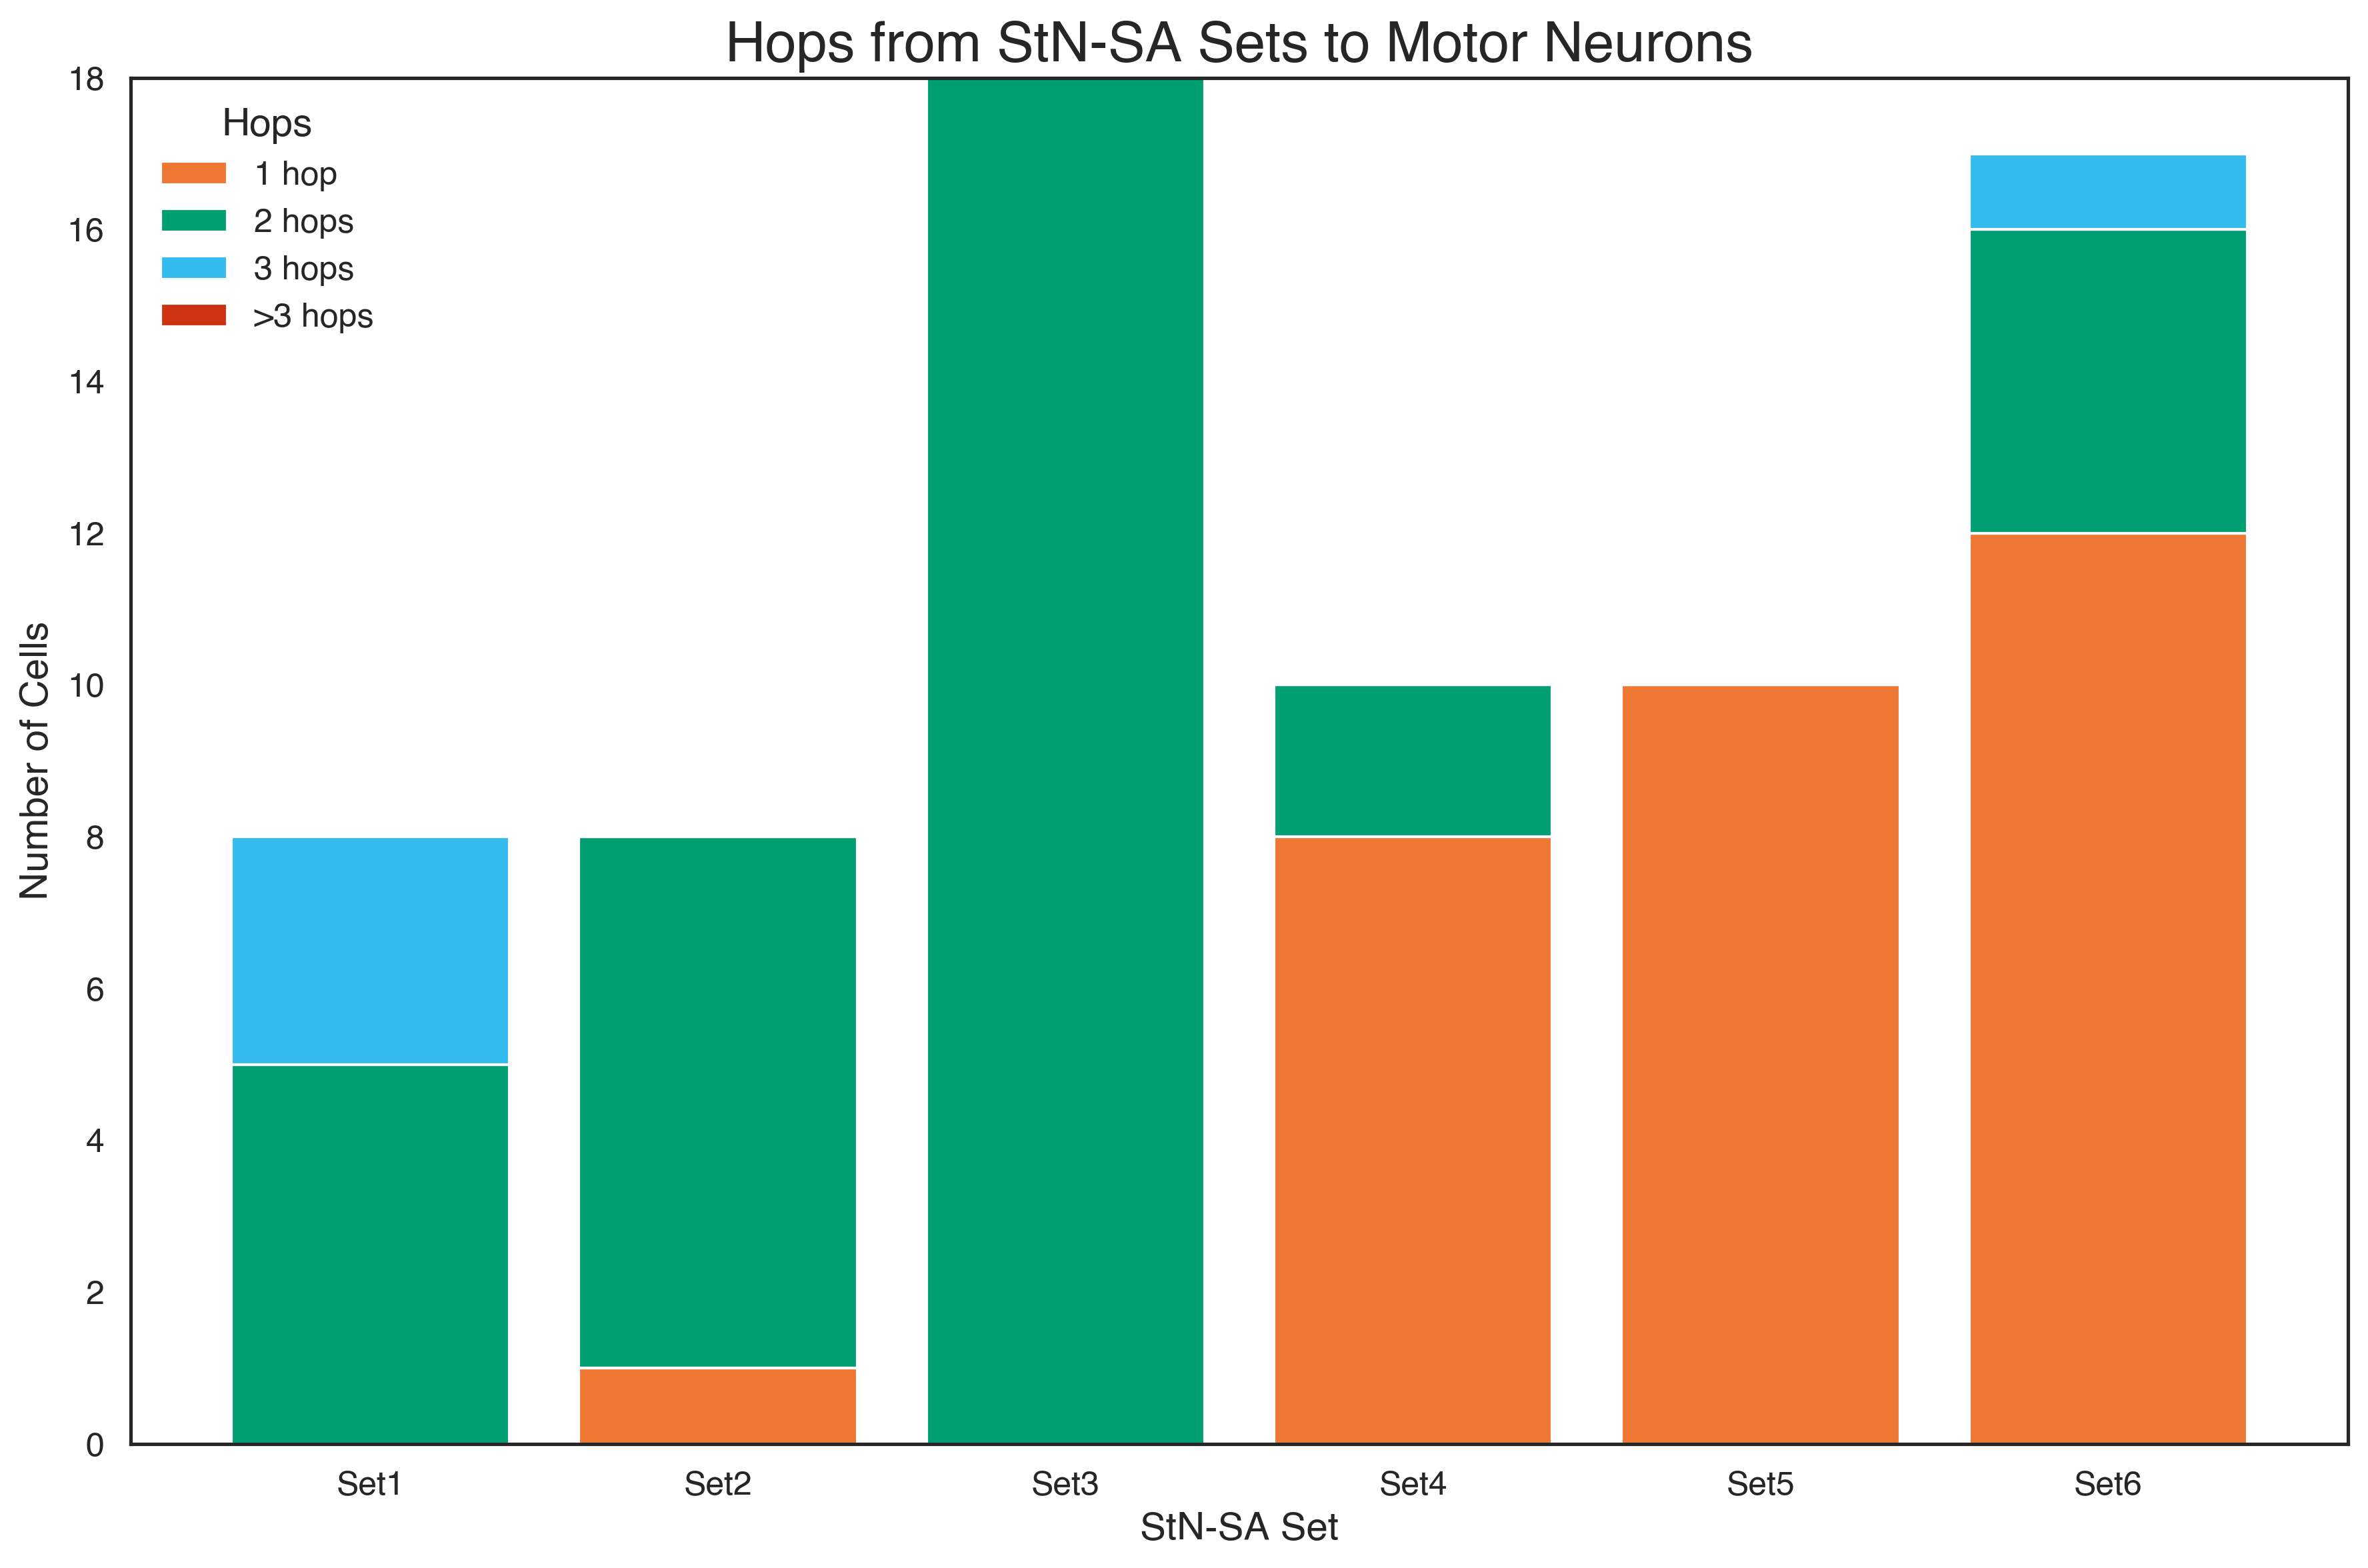

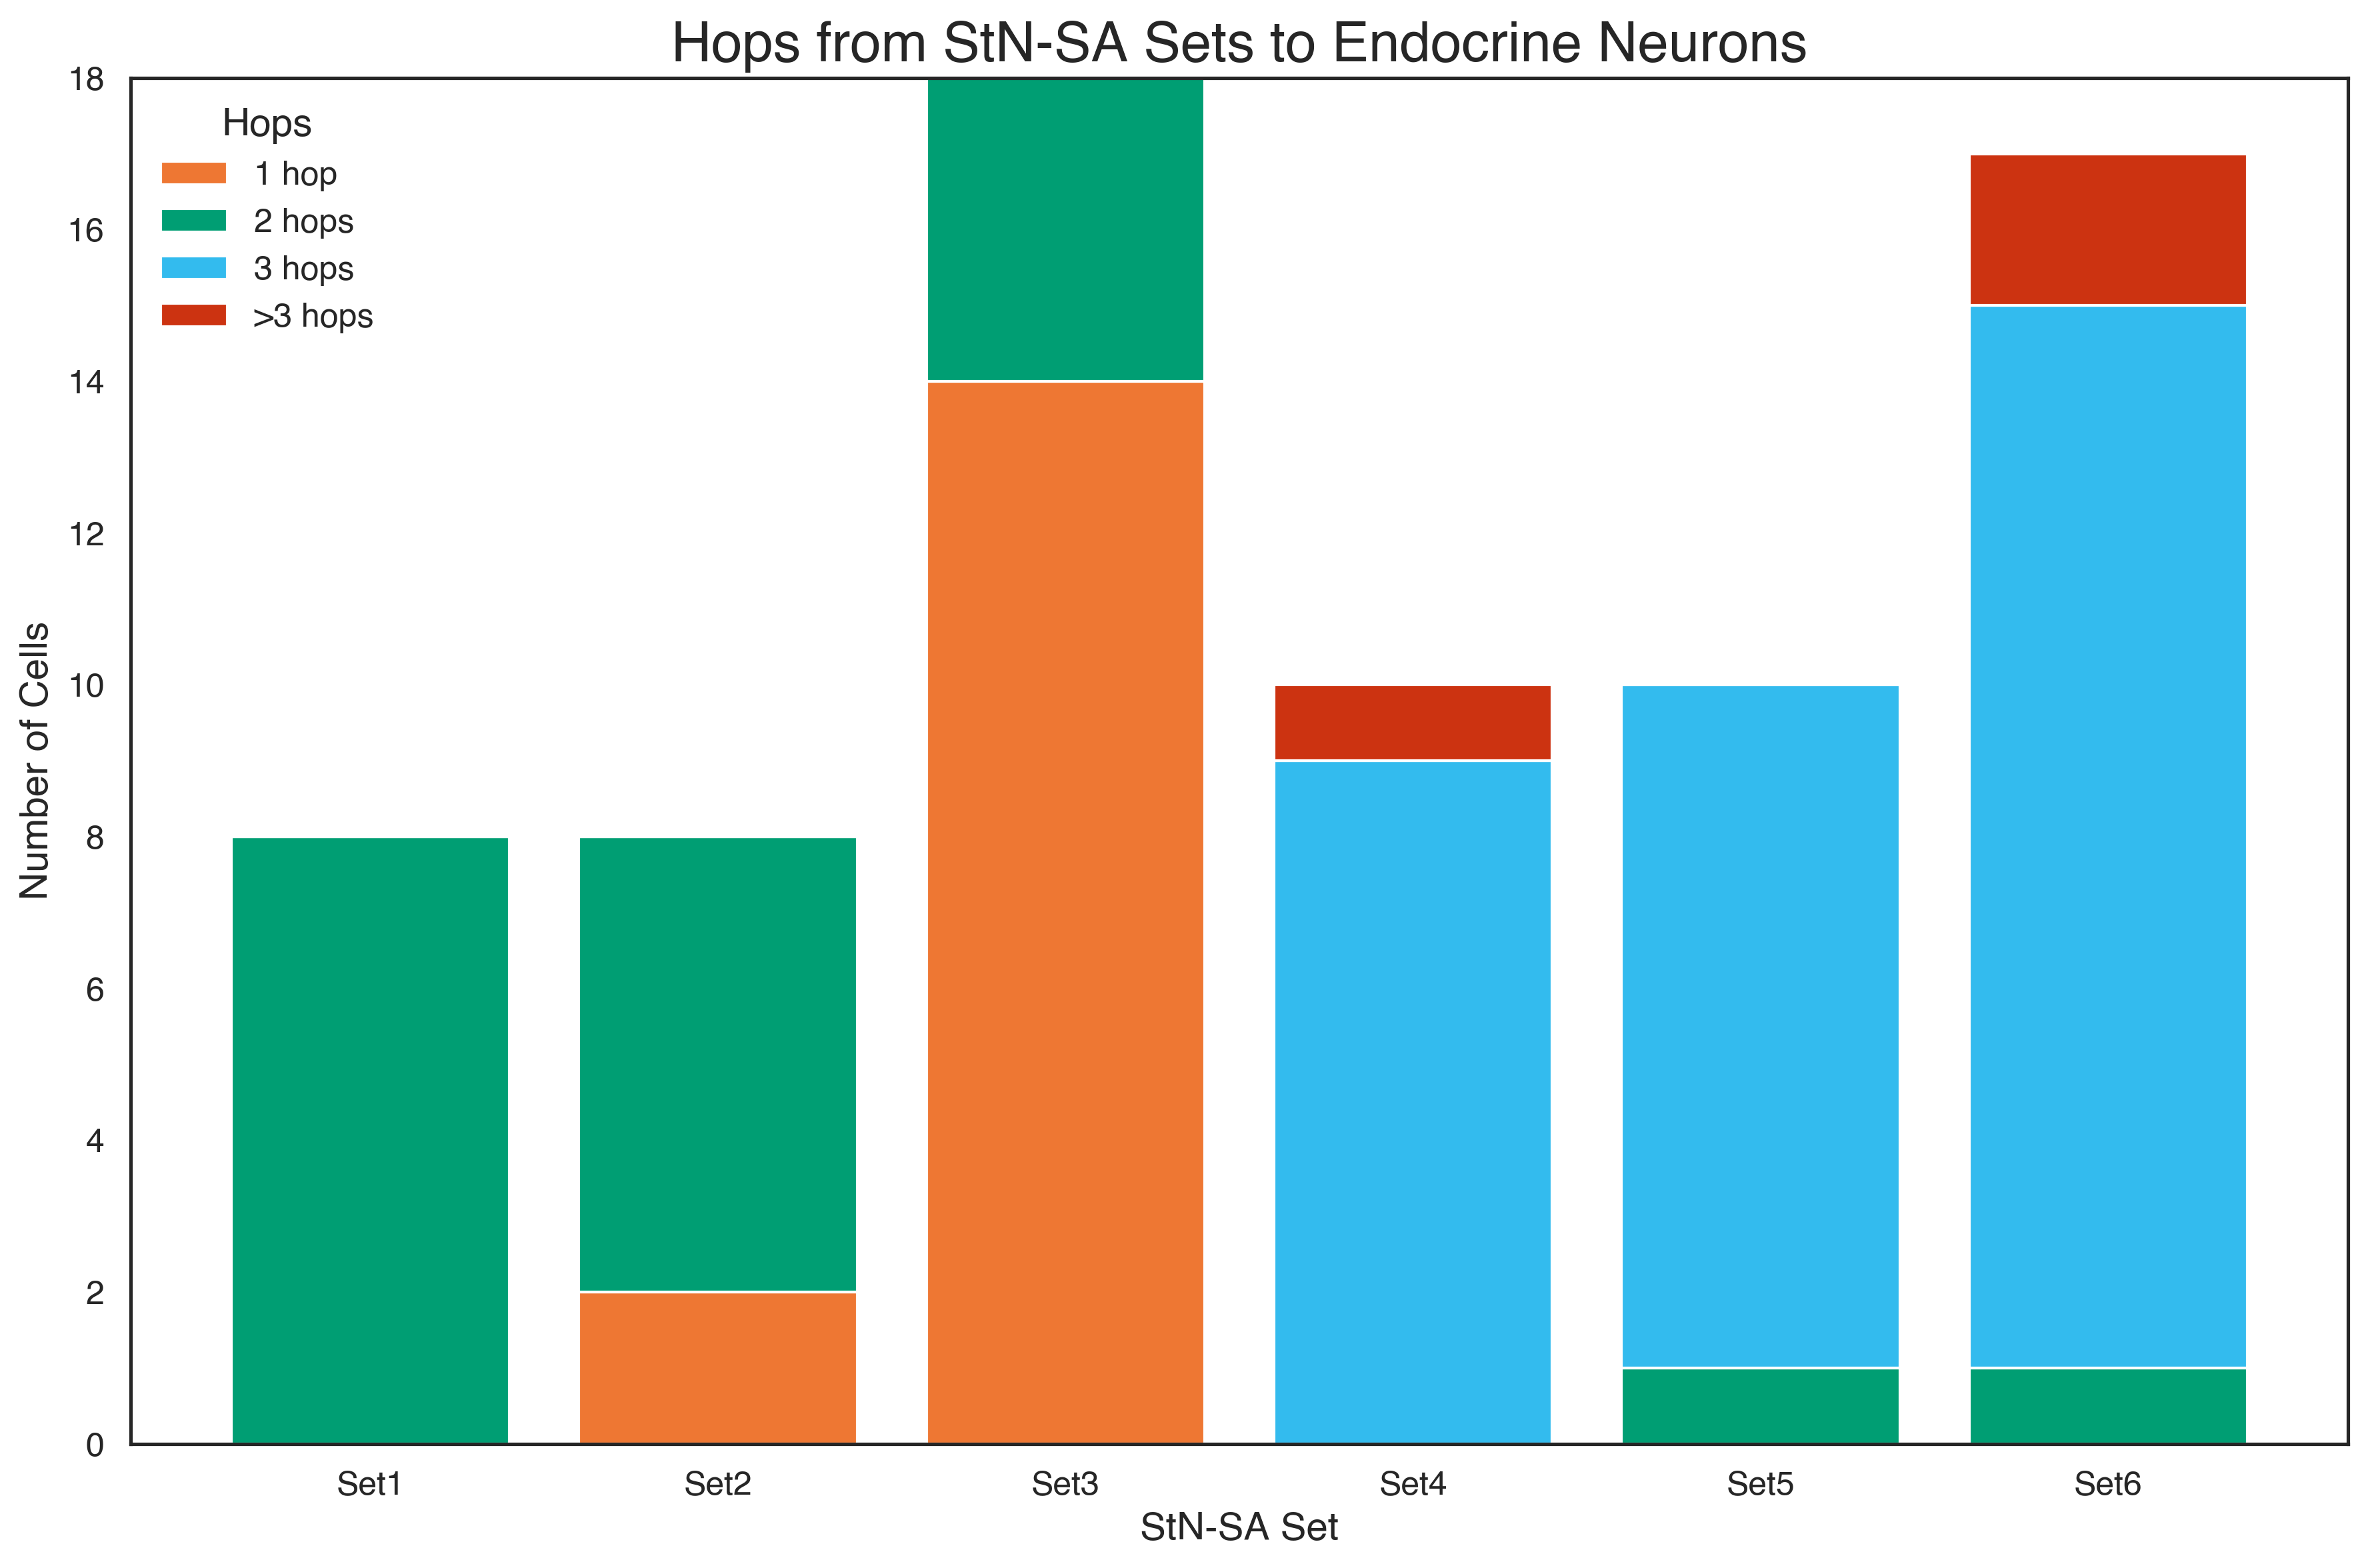

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque, defaultdict

# ───────────────────────────────────────────────────────────────────────────────
# 0. LOAD ALL YOUR DATASETS
# ───────────────────────────────────────────────────────────────────────────────
connections = pd.read_csv(
    CONNECTIONS_PATH
)

neuropil_synapse = (
    pd.read_csv(
        NEUROPIL_SYNAPSE_PATH
    )
    [['root_id','input synapses','output synapses']]
    .rename(columns={
        'input synapses':'input_synapses',
        'output synapses':'output_synapses'
    })
)

classification_side = pd.read_csv(
    CLASSIFICATION_PATH
)[['root_id','side']]

classification_other = pd.read_csv(
    CLASSIFICATION_PATH
)[['root_id','super_class']]

super_map = classification_other.set_index('root_id')['super_class'].to_dict()

neurons = pd.read_csv(
    NEURONS_PATH
)[['root_id','nt_type']]

neurons_data = pd.merge(
    neurons,
    pd.merge(classification_side, neuropil_synapse, on='root_id', how='outer'),
    on='root_id',
    how='outer'
)

# ───────────────────────────────────────────────────────────────────────────────
# 1. BUILD THRESHOLDED ADJACENCY LIST (≥5 synapses)
# ───────────────────────────────────────────────────────────────────────────────
edge_df = (
    connections
    .groupby(['pre_root_id','post_root_id'], as_index=False)
    .agg({'syn_count':'sum'})
    .query('syn_count >= 5')
    [['pre_root_id','post_root_id']]
)

adj = defaultdict(set)
for u, v in edge_df.values:
    adj[int(u)].add(int(v))

# ───────────────────────────────────────────────────────────────────────────────
# 2. LOAD YOUR SIX StN-SA_v2 SETS & DEFINE THE “sets” DICT
# ───────────────────────────────────────────────────────────────────────────────
sets = {
    f'Set{i}': pd.read_csv(
        PROJECT_ROOT / 'input' / 'PhN' / f'set_{i}.csv'
    )['root_id'].astype(int)
    for i in range(1, 7)
}

# ───────────────────────────────────────────────────────────────────────────────
# 3. BFS HELPER TO COMPUTE MINIMAL HOPS TO A TARGET CLASS
# ───────────────────────────────────────────────────────────────────────────────
def compute_hops(src_ids, target_class):
    hop_of = {}
    for src in src_ids:
        if src not in adj:
            hop_of[src] = None
            continue

        visited = {src}
        queue = deque([(src, 0)])
        found = None

        while queue and found is None:
            node, dist = queue.popleft()
            if dist >= 3:
                continue
            for nei in adj[node]:
                if nei in visited:
                    continue
                visited.add(nei)
                nd = dist + 1
                if super_map.get(nei) == target_class:
                    found = nd
                    break
                queue.append((nei, nd))

        hop_of[src] = found

    counts = {'1':0,'2':0,'3':0,'>3':0}
    for h in hop_of.values():
        if h in (1,2,3):
            counts[str(h)] += 1
        else:
            counts['>3'] += 1

    return pd.DataFrame({
        'hop':  ['1','2','3','>3'],
        'count':[counts['1'],counts['2'],counts['3'],counts['>3']]
    })

# ───────────────────────────────────────────────────────────────────────────────
# 4. RUN FOR “motor” AND “endocrine” & PLOT STACKED BARS
# ───────────────────────────────────────────────────────────────────────────────
custom_colors = [
    '#EE7733',  # Vibrant Orange
    '#009E73',  # Vivid Blue
    '#33BBEE',  # Cyan
    '#CC3311'   # Red
]

for target in ['motor','endocrine']:
    all_df = []
    for label, ids in sets.items():
        df_h = compute_hops(ids, target)
        df_h['set'] = label
        all_df.append(df_h)

    df_stack = pd.concat(all_df, ignore_index=True)
    df_stack['hop'] = pd.Categorical(df_stack['hop'], ['1','2','3','>3'], ordered=True)
    df_stack['set'] = pd.Categorical(df_stack['set'], list(sets.keys()), ordered=True)

    pivot = df_stack.pivot(index='set', columns='hop', values='count').fillna(0)

    fig, ax = plt.subplots(figsize=(12,8))
    bottom = np.zeros(len(pivot), dtype=int)
    for i, hop in enumerate(['1','2','3','>3']):
        ax.bar(pivot.index, pivot[hop], bottom=bottom,
               color=custom_colors[i],
               label=f"{hop} hop{'s' if hop!='1' else ''}")
        bottom += pivot[hop].values

    ax.set_title(f"Hops from StN-SA Sets to {target.capitalize()} Neurons", fontsize=20)
    ax.set_xlabel("StN-SA Set", fontsize=14)
    ax.set_ylabel("Number of Cells", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(title="Hops", frameon=False, prop={'size':12})

    fig.set_size_inches(12, 8)
    #fig.savefig(FIG_7_DIR / f'hops_to_{target}.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


In [11]:
for target in ['motor','endocrine']:
    # … all your plotting code …

    plt.tight_layout()
    # define a filename based on the target
    filename = FIG_7_DIR / f'hops_to_{target}.svg'
    # save it out at 1200×800px
    fig.set_size_inches(12, 8)
    #fig.savefig(filename, format='svg', dpi=300, bbox_inches='tight')
    plt.show()


<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

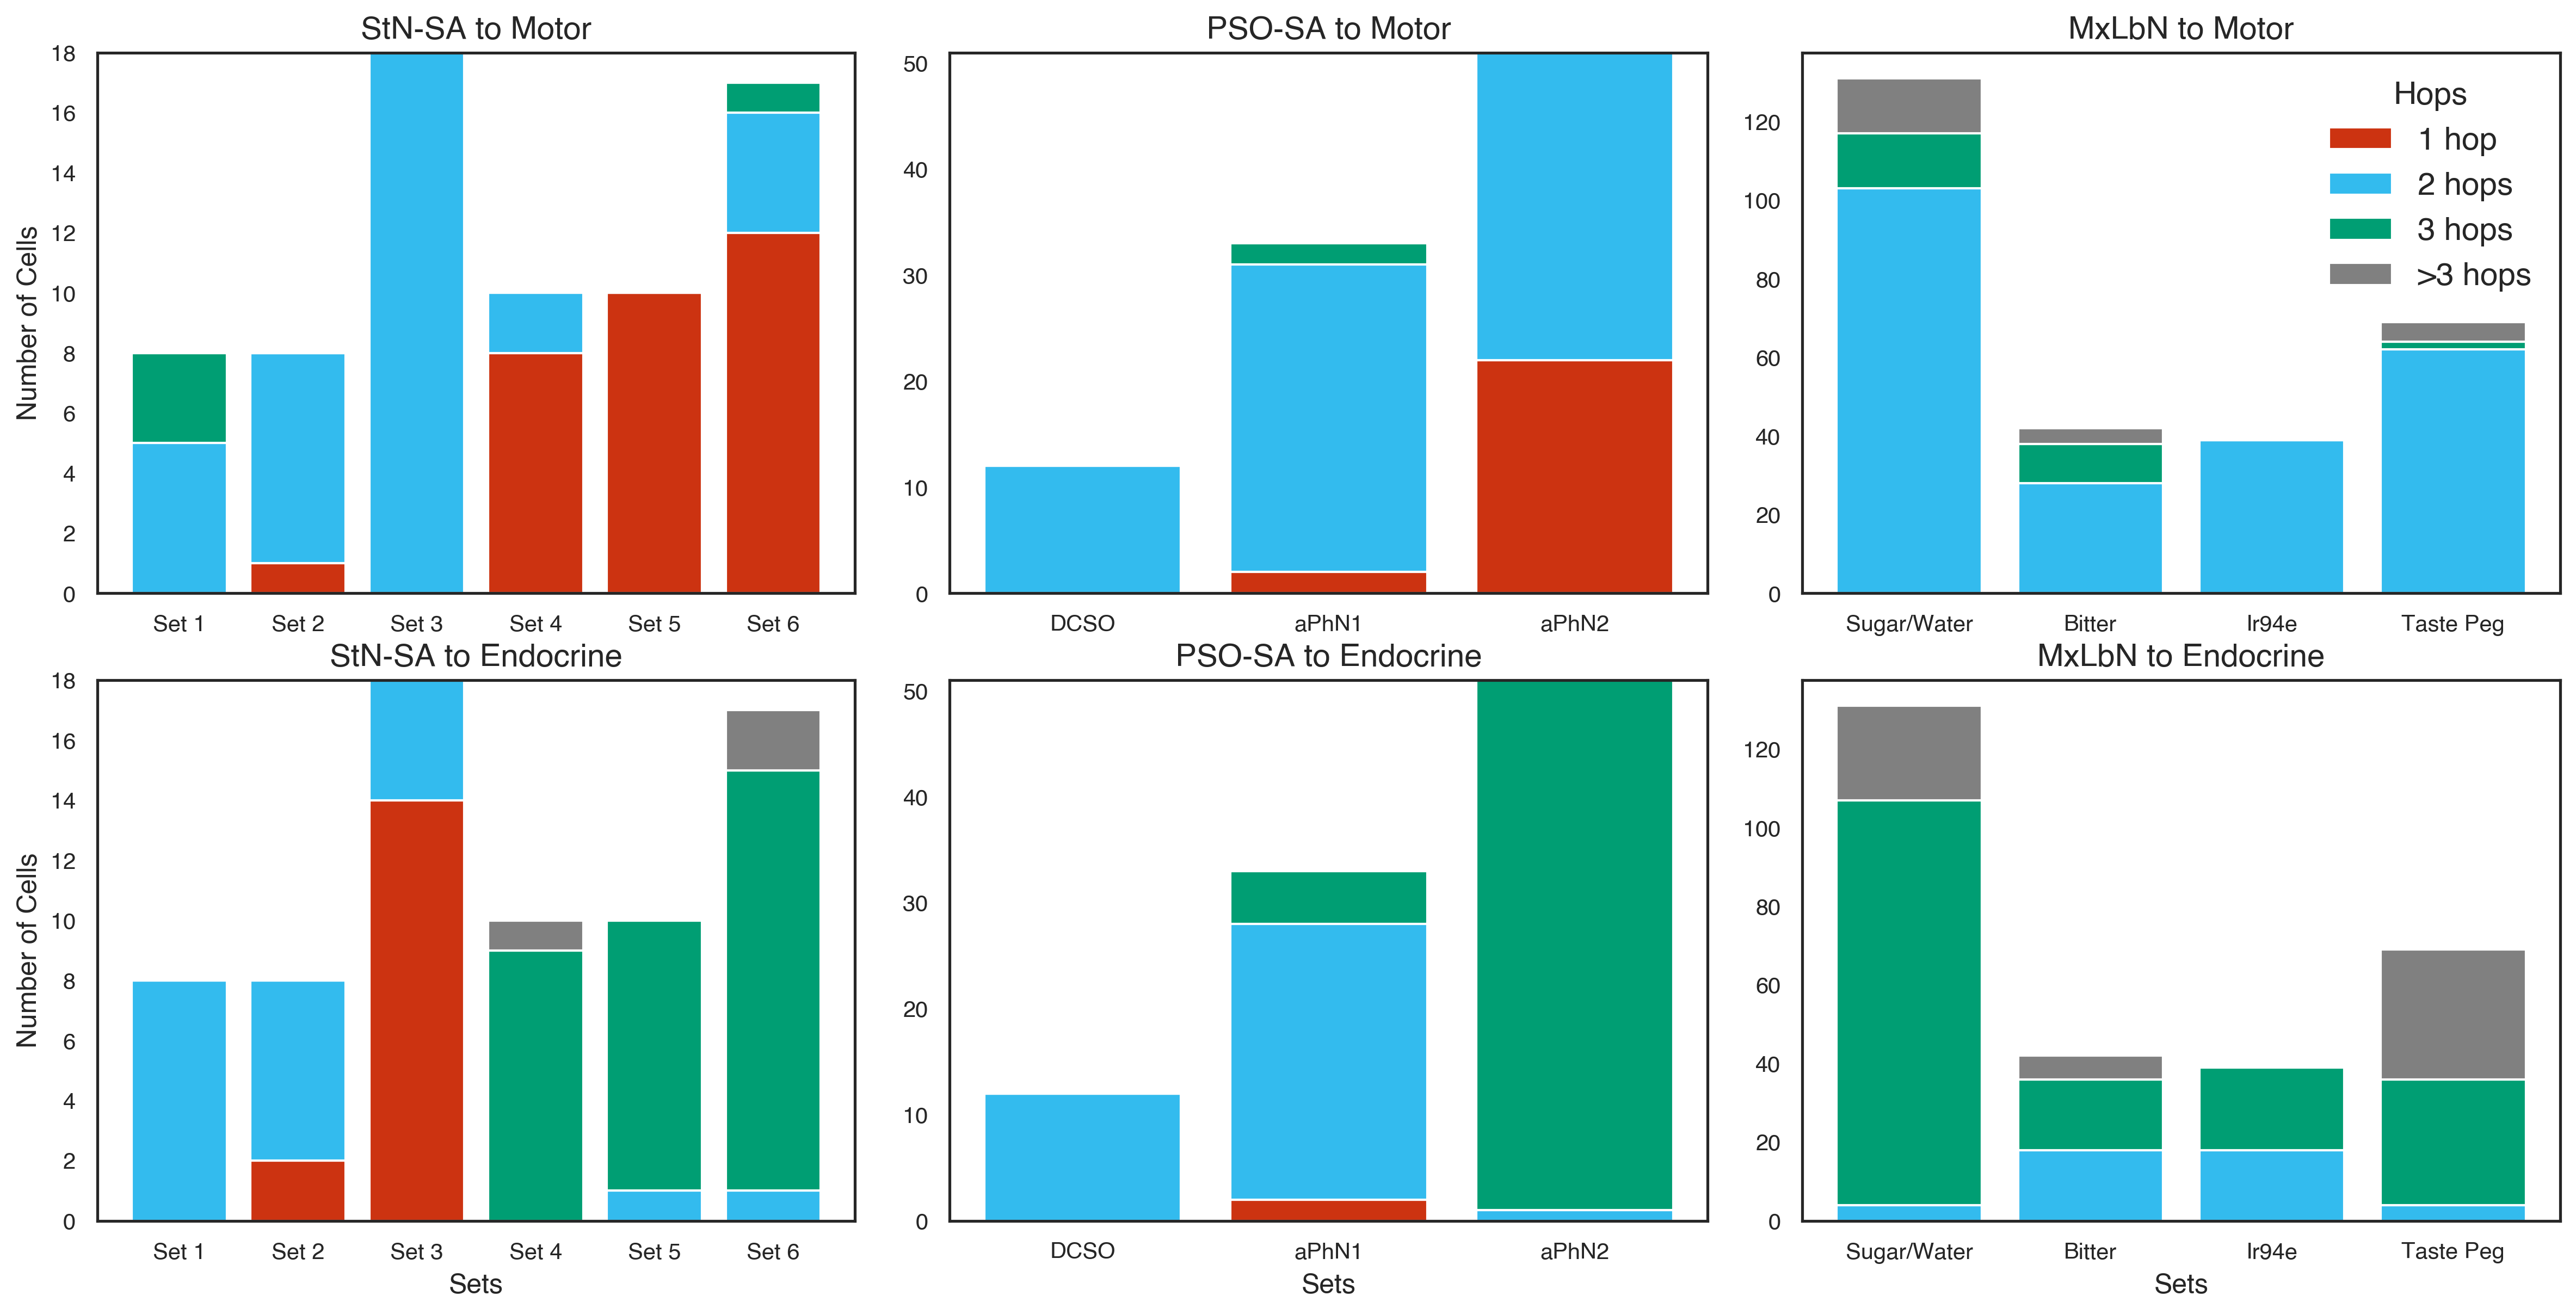

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque, defaultdict

# ───────────────────────────────────────────────────────────────────────────────
# 0. LOAD SHARED DATA: connectome + classification + build adjacency & super_map
# ───────────────────────────────────────────────────────────────────────────────
connections = pd.read_csv(
    CONNECTIONS_PATH
)
classification = pd.read_csv(
    CLASSIFICATION_PATH
)[['root_id', 'super_class']]

edge_df = (
    connections
    .groupby(['pre_root_id', 'post_root_id'], as_index=False)
    .agg({'syn_count': 'sum'})
    .query('syn_count >= 5')
)[['pre_root_id', 'post_root_id']]

adj = defaultdict(set)
for u, v in edge_df.values:
    adj[int(u)].add(int(v))

super_map = classification.set_index('root_id')['super_class'].to_dict()

def compute_hops(src_ids, target_class):
    hop_of = {}
    for src in src_ids:
        if src not in adj:
            hop_of[src] = None
            continue
        visited = {src}
        queue = deque([(src, 0)])
        found = None
        while queue and found is None:
            node, dist = queue.popleft()
            if dist >= 3:
                continue
            for nei in adj[node]:
                if nei in visited:
                    continue
                visited.add(nei)
                nd = dist + 1
                if super_map.get(nei) == target_class:
                    found = nd
                    break
                queue.append((nei, nd))
        hop_of[src] = found
    counts = {'1':0,'2':0,'3':0,'>3':0}
    for h in hop_of.values():
        if h in (1,2,3):
            counts[str(h)] += 1
        else:
            counts['>3'] += 1
    return pd.DataFrame({
        'hop': ['1','2','3','>3'],
        'count': [counts['1'], counts['2'], counts['3'], counts['>3']]
    })

# ───────────────────────────────────────────────────────────────────────────────
# 1. DEFINE WORKFLOWS
# ───────────────────────────────────────────────────────────────────────────────
workflows = []

# StN-SA_v2 (6 sets)
stn_sets = {
    f'Set {i}': pd.read_csv(
        PROJECT_ROOT / 'input' / 'PhN' / f'set_{i}.csv'
    )['root_id'].astype(int)
    for i in range(1, 7)
}
workflows.append(('StN-SA', stn_sets))

# PSO (3 sets)
PSO_paths = {
    'DCSO':  PROJECT_ROOT / 'input' / 'PSO_SA' / 'set_1.csv',
    'aPhN1': PROJECT_ROOT / 'input' / 'PSO_SA' / 'set_2.csv',
    'aPhN2': PROJECT_ROOT / 'input' / 'PSO_SA' / 'set_3.csv',
}
PSO_sets = {name: pd.read_csv(path)['root_id'].astype(int)
            for name, path in PSO_paths.items()}
workflows.append(('PSO-SA', PSO_sets))

# MxLbN GRNs (4 sets)
grn_paths = {
    'Sugar/Water': PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'sugar_water_GRNs.csv',
    'Bitter':      PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'bitter_GRNs.csv',
    'Ir94e':       PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'Ir94e_GRNs.csv',
    'Taste Peg':   PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'taste_peg_GRNs.csv',
}
grn_sets = {name: pd.read_csv(path)['root_id'].astype(int)
            for name, path in grn_paths.items()}
workflows.append(('MxLbN', grn_sets))



# ───────────────────────────────────────────────────────────────────────────────
# 2. PLOT 2×3 GRID: motor on top row, endocrine on bottom row
# ───────────────────────────────────────────────────────────────────────────────
targets = ['motor', 'endocrine']
custom_colors = ['#CC3311', '#33BBEE', '#009E73', 'gray']

n_workflows = len(workflows)
fig, axes = plt.subplots(2, n_workflows, figsize=(n_workflows * 5, 10), sharey=False)

for row, target in enumerate(targets):
    for col, (wf_name, sets_dict) in enumerate(workflows):
        ax = axes[row, col]

        # ---- compute and pivot ----
        all_df = []
        for label, ids in sets_dict.items():
            df_h = compute_hops(ids, target)
            df_h['set'] = label
            all_df.append(df_h)
        df_stack = pd.concat(all_df, ignore_index=True)
        df_stack['hop'] = pd.Categorical(df_stack['hop'], ['1','2','3','>3'], ordered=True)
        df_stack['set'] = pd.Categorical(df_stack['set'], list(sets_dict.keys()), ordered=True)
        pivot = df_stack.pivot(index='set', columns='hop', values='count').fillna(0)

        # ---- stacked bars ----
        bottom = np.zeros(len(pivot), dtype=int)
        for k, hop in enumerate(['1','2','3','>3']):
            ax.bar(
                pivot.index, pivot[hop], bottom=bottom,
                color=custom_colors[k],
                label=f"{hop} hop{'s' if hop!='1' else ''}"
            )
            bottom += pivot[hop].values

        # ---- labels & titles ----
        ax.set_title(f"{wf_name} to {target.capitalize()}", fontsize=14)
        if row == 1:
            ax.set_xlabel("Sets", fontsize=12)
        if col == 0:
            ax.set_ylabel("Number of Cells", fontsize=12)
        ax.tick_params(labelsize=10)

        # ← legend only in top-right panel
        if (row == 0) and (col == n_workflows - 1):
            ax.legend(title="Hops", frameon=False)

plt.tight_layout()
filename = FIG_7_DIR / f'hops_to_{target}_subplot.svg'
# save it out at 1200×800px
fig.set_size_inches(16,8)
#fig.savefig(filename, format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
#!/usr/bin/env python3
import pandas as pd
from pathlib import Path
from collections import defaultdict, deque

# ───────────────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION
# ───────────────────────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "flywire_data"
SETS_DIR = PROJECT_ROOT / "input" / "PhN"
OUT_DIR = FIG_7_DATA_DIR
MIN_SYN = 5

OUT_DIR.mkdir(exist_ok=True)

# ───────────────────────────────────────────────────────────────────────────────
# 1. LOAD FLYWIRE TABLES
# ───────────────────────────────────────────────────────────────────────────────
conns = pd.read_csv(
    CONNECTIONS_PATH,
    usecols=["pre_root_id", "post_root_id", "syn_count"]
)
clsf = pd.read_csv(
    CLASSIFICATION_PATH,
    usecols=["root_id", "super_class"]
)

# build adjacency list for edges with ≥ MIN_SYN synapses
adj = defaultdict(set)
for pre, post, cnt in conns.itertuples(index=False):
    if cnt >= MIN_SYN:
        adj[int(pre)].add(int(post))

# lookup table for super_class
super_map = clsf.set_index("root_id")["super_class"].to_dict()


# ───────────────────────────────────────────────────────────────────────────────
# 2. HELPER: BFS to find shortest path from a sensory axon to any motor neuron
# ───────────────────────────────────────────────────────────────────────────────
def find_path_to_motor(src):
    """Return the hop-by-hop path from src to the nearest motor neuron, or None."""
    if super_map.get(src) == "motor":
        return [src]
    visited = {src}
    parent = {src: None}
    queue = deque([src])
    while queue:
        node = queue.popleft()
        for nei in adj[node]:
            if nei in visited:
                continue
            visited.add(nei)
            parent[nei] = node
            if super_map.get(nei) == "motor":
                # reconstruct path backward
                path = [nei]
                while parent[path[-1]] is not None:
                    path.append(parent[path[-1]])
                return list(reversed(path))
            queue.append(nei)
    return None


# ───────────────────────────────────────────────────────────────────────────────
# 3. PROCESS EACH StN-SA SET
# ───────────────────────────────────────────────────────────────────────────────
for i in range(1, 7):
    set_name = f"Set_{i}"
    sensory = pd.read_csv(SETS_DIR / f"set_{i}.csv")["root_id"].astype(int).unique()

    # 3a) find all paths and track maximum length
    paths = {}
    max_len = 0
    for src in sensory:
        p = find_path_to_motor(src)
        paths[src] = p
        if p is not None:
            max_len = max(max_len, len(p))

    # 3b) build a DataFrame with fixed columns ['src','path_found','hop_0',...,'hop_{max_len-1}']
    cols = ["src", "path_found"] + [f"hop_{h}" for h in range(max_len)]
    rows = []
    for src, p in paths.items():
        row = [src, bool(p)]
        if p is None:
            row += [""] * max_len
        else:
            # pad p to length max_len with empty strings
            row += p + [""] * (max_len - len(p))
        rows.append(row)

    df_paths = pd.DataFrame(rows, columns=cols)

    # ───────────────────────────────────────────────────────────────────────────
    # 4. SAVE TO CSV
    # ───────────────────────────────────────────────────────────────────────────
    out_csv = OUT_DIR / f"{set_name}_sensory_to_motor_paths.csv"
    df_paths.to_csv(out_csv, index=False)
    print(f"Wrote {len(df_paths)} rows → {out_csv}")


Wrote 8 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_1_sensory_to_motor_paths.csv
Wrote 8 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_2_sensory_to_motor_paths.csv
Wrote 18 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_3_sensory_to_motor_paths.csv
Wrote 10 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_4_sensory_to_motor_paths.csv
Wrote 10 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_5_sensory_to_motor_paths.csv
Wrote 17 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_6_sensory_to_motor_paths.csv


In [14]:
#!/usr/bin/env python3
import pandas as pd
from pathlib import Path
from collections import defaultdict, deque

# ───────────────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION
# ───────────────────────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "flywire_data"
SETS_DIR = PROJECT_ROOT / "input" / "PhN"
OUT_DIR = FIG_7_DATA_DIR
MIN_SYN = 5

OUT_DIR.mkdir(exist_ok=True)

# ───────────────────────────────────────────────────────────────────────────────
# 1. LOAD FLYWIRE TABLES
# ───────────────────────────────────────────────────────────────────────────────
conns = pd.read_csv(
    CONNECTIONS_PATH,
    usecols=["pre_root_id", "post_root_id", "syn_count"]
)
clsf = pd.read_csv(
    CLASSIFICATION_PATH,
    usecols=["root_id", "super_class"]
)

# build adjacency list for edges with ≥ MIN_SYN synapses
adj = defaultdict(set)
for pre, post, cnt in conns.itertuples(index=False):
    if cnt >= MIN_SYN:
        adj[int(pre)].add(int(post))

# lookup table for super_class
super_map = clsf.set_index("root_id")["super_class"].to_dict()


# ───────────────────────────────────────────────────────────────────────────────
# 2. HELPER: find all shortest paths from src to every motor neuron
# ───────────────────────────────────────────────────────────────────────────────
def find_all_motor_paths(src):
    """Return dict motor_id → list of all shortest paths (each path a list of nodes)."""
    parents = defaultdict(list)
    dist = {src: 0}
    queue = deque([src])
    found_motor_level = None
    motors = set()

    while queue:
        node = queue.popleft()
        d = dist[node]
        if found_motor_level is not None and d >= found_motor_level:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            if dist[nei] == nd:
                parents[nei].append(node)
            if super_map.get(nei) == "motor":
                motors.add(nei)
                if found_motor_level is None or nd < found_motor_level:
                    found_motor_level = nd

    if not motors:
        return {}

    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths

    all_paths = {}
    for m in motors:
        all_paths[m] = build_paths(m)
    return all_paths


# ───────────────────────────────────────────────────────────────────────────────
# 3. PROCESS EACH StN-SA SET
# ───────────────────────────────────────────────────────────────────────────────
for i in range(1, 7):
    set_name = f"Set_{i}"
    sensory = pd.read_csv(SETS_DIR / f"set_{i}.csv")["root_id"].astype(int).unique()

    # collect raw records: (src, motor, path_list)
    raw = []
    for src in sensory:
        motor_paths = find_all_motor_paths(src)
        if not motor_paths:
            raw.append((src, None, []))
        else:
            for motor_id, paths in motor_paths.items():
                for path in paths:
                    raw.append((src, motor_id, path))

    # determine max path length across all records
    max_len = max((len(path) for _, _, path in raw), default=0)

    # build DataFrame rows with hop_ columns
    cols = ["src", "motor", "path_found"] + [f"hop_{h}" for h in range(max_len)]
    rows = []
    for src, motor_id, path in raw:
        row = {
            "src": src,
            "motor": motor_id if motor_id is not None else "",
            "path_found": bool(path)
        }
        # pad path to max_len
        for h in range(max_len):
            row[f"hop_{h}"] = path[h] if h < len(path) else ""
        rows.append(row)

    df_paths = pd.DataFrame(rows, columns=cols)

    # save CSV
    out_csv = OUT_DIR / f"{set_name}_sensory_to_motor_paths.csv"
    df_paths.to_csv(out_csv, index=False)
    print(f"Wrote {len(df_paths)} rows → {out_csv}")


Wrote 264 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_1_sensory_to_motor_paths.csv
Wrote 226 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_2_sensory_to_motor_paths.csv
Wrote 510 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_3_sensory_to_motor_paths.csv
Wrote 162 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_4_sensory_to_motor_paths.csv
Wrote 32 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_5_sensory_to_motor_paths.csv
Wrote 98 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_6_sensory_to_motor_paths.csv


In [15]:
#!/usr/bin/env python3
import pandas as pd
from pathlib import Path
from collections import defaultdict, deque

# ───────────────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION
# ───────────────────────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "flywire_data"
SETS_DIR = PROJECT_ROOT / "input" / "PhN"
OUT_DIR = FIG_7_DATA_DIR
MIN_SYN = 5

OUT_DIR.mkdir(exist_ok=True)

# ───────────────────────────────────────────────────────────────────────────────
# 1. LOAD FLYWIRE TABLES
# ───────────────────────────────────────────────────────────────────────────────
conns = pd.read_csv(
    CONNECTIONS_PATH,
    usecols=["pre_root_id", "post_root_id", "syn_count"]
)
clsf = pd.read_csv(
    CLASSIFICATION_PATH,
    usecols=["root_id", "super_class"]
)

# build adjacency list for edges with ≥ MIN_SYN synapses
adj = defaultdict(set)
for pre, post, cnt in conns.itertuples(index=False):
    if cnt >= MIN_SYN:
        adj[int(pre)].add(int(post))

# lookup table for super_class
super_map = clsf.set_index("root_id")["super_class"].to_dict()


# ───────────────────────────────────────────────────────────────────────────────
# 2. HELPER: find all shortest paths from src to every motor neuron
# ───────────────────────────────────────────────────────────────────────────────
def find_all_motor_paths(src):
    """Return dict motor_id → list of all shortest paths (each path a list of nodes)."""
    parents = defaultdict(list)
    dist = {src: 0}
    queue = deque([src])
    found_motor_level = None
    motors = set()

    while queue:
        node = queue.popleft()
        d = dist[node]
        if found_motor_level is not None and d >= found_motor_level:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            if dist[nei] == nd:
                parents[nei].append(node)
            if super_map.get(nei) == "motor":
                motors.add(nei)
                if found_motor_level is None or nd < found_motor_level:
                    found_motor_level = nd

    if not motors:
        return {}

    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths

    all_paths = {}
    for m in motors:
        all_paths[m] = build_paths(m)
    return all_paths


# ───────────────────────────────────────────────────────────────────────────────
# 3. PROCESS EACH StN-SA SET
# ───────────────────────────────────────────────────────────────────────────────
for i in range(1, 7):
    set_name = f"Set_{i}"
    sensory = pd.read_csv(SETS_DIR / f"set_{i}.csv")["root_id"].astype(int).unique()

    # collect raw records: (src, motor, path_list)
    raw = []
    for src in sensory:
        motor_paths = find_all_motor_paths(src)
        if not motor_paths:
            raw.append((src, None, []))
        else:
            for motor_id, paths in motor_paths.items():
                for path in paths:
                    raw.append((src, motor_id, path))

    # determine max path length across all records
    max_len = max((len(path) for _, _, path in raw), default=0)

    # build DataFrame rows with hop_ columns
    cols = ["src", "motor", "path_found"] + [f"hop_{h}" for h in range(max_len)]
    rows = []
    for src, motor_id, path in raw:
        row = {
            "src": src,
            "motor": motor_id if motor_id is not None else "",
            "path_found": bool(path)
        }
        # pad path to max_len
        for h in range(max_len):
            row[f"hop_{h}"] = path[h] if h < len(path) else ""
        rows.append(row)

    df_paths = pd.DataFrame(rows, columns=cols)

    # save CSV
    out_csv = OUT_DIR / f"{set_name}_sensory_to_motor_paths.csv"
    df_paths.to_csv(out_csv, index=False)
    print(f"Wrote {len(df_paths)} rows → {out_csv}")


Wrote 264 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_1_sensory_to_motor_paths.csv
Wrote 226 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_2_sensory_to_motor_paths.csv
Wrote 510 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_3_sensory_to_motor_paths.csv
Wrote 162 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_4_sensory_to_motor_paths.csv
Wrote 32 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_5_sensory_to_motor_paths.csv
Wrote 98 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/Set_6_sensory_to_motor_paths.csv


In [16]:
#!/usr/bin/env python3
import re
import pandas as pd
from pathlib import Path
from collections import defaultdict, deque

# ───────────────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION
# ───────────────────────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "flywire_data"
OUT_DIR  = FIG_7_DATA_DIR
MIN_SYN  = 5

OUT_DIR.mkdir(exist_ok=True, parents=True)

# ───────────────────────────────────────────────────────────────────────────────
# 1. LOAD FLYWIRE TABLES & BUILD ADJACENCY
# ───────────────────────────────────────────────────────────────────────────────
conns = pd.read_csv(
    CONNECTIONS_PATH,
    usecols=["pre_root_id", "post_root_id", "syn_count"]
)
clsf = pd.read_csv(
    CLASSIFICATION_PATH,
    usecols=["root_id", "super_class"]
)

adj = defaultdict(set)
for pre, post, cnt in conns.itertuples(index=False):
    if cnt >= MIN_SYN:
        adj[int(pre)].add(int(post))

super_map = clsf.set_index("root_id")["super_class"].to_dict()

# ───────────────────────────────────────────────────────────────────────────────
# 2. HELPER: FIND ALL SHORTEST PATHS TO MOTOR NEURONS
# ───────────────────────────────────────────────────────────────────────────────
def find_all_motor_paths(src):
    parents       = defaultdict(list)
    dist          = {src: 0}
    queue         = deque([src])
    found_level   = None
    motors        = set()

    while queue:
        node = queue.popleft()
        d    = dist[node]
        if found_level is not None and d >= found_level:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            if dist[nei] == nd:
                parents[nei].append(node)
            if super_map.get(nei) == "motor":
                motors.add(nei)
                if found_level is None or nd < found_level:
                    found_level = nd

    if not motors:
        return {}

    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths

    return {m: build_paths(m) for m in motors}

# ───────────────────────────────────────────────────────────────────────────────
# 3. DEFINE WORKFLOWS & SETS (with your correct file paths)
# ───────────────────────────────────────────────────────────────────────────────
workflows = []

# (a) StN-SA_v2 (6 sets)
stn_sets = {
    f"Set {i}": pd.read_csv(
        PROJECT_ROOT / 'input' / 'PhN' / f'set_{i}.csv'
    )["root_id"].astype(int)
    for i in range(1, 7)
}
workflows.append(("StN-SA", stn_sets))

# (b) PSO-SA (3 sets)
PSO_paths = {
    "DCSO":  PROJECT_ROOT / 'input' / 'PSO_SA' / 'set_1.csv',
    "aPhN1": PROJECT_ROOT / 'input' / 'PSO_SA' / 'set_2.csv',
    "aPhN2": PROJECT_ROOT / 'input' / 'PSO_SA' / 'set_3.csv',
}
PSO_sets = {name: pd.read_csv(path)["root_id"].astype(int) for name, path in PSO_paths.items()}
workflows.append(("PSO-SA", PSO_sets))

# (c) MxLbN GRNs (4 sets)
grn_paths = {
    "Sugar/Water": PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'sugar_water_GRNs.csv',
    "Bitter":      PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'bitter_GRNs.csv',
    "Ir94e":       PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'Ir94e_GRNs.csv',
    "Taste Peg":   PROJECT_ROOT / 'input' / 'MxLbN-SA' / 'taste_peg_GRNs.csv',
}
grn_sets = {name: pd.read_csv(path)["root_id"].astype(int) for name, path in grn_paths.items()}
workflows.append(("MxLbN", grn_sets))

# ───────────────────────────────────────────────────────────────────────────────
# 4. PROCESS EACH WORKFLOW & SET
# ───────────────────────────────────────────────────────────────────────────────
def sanitize(name: str) -> str:
    # replace any non-alphanumeric char with underscore
    return re.sub(r'[^0-9A-Za-z]+', '_', name).strip('_')

for wf_name, sets_dict in workflows:
    wf_safe = sanitize(wf_name)
    for set_label, ids in sets_dict.items():
        set_safe = sanitize(set_label)
        raw = []
        for src in ids.unique():
            motor_paths = find_all_motor_paths(src)
            if not motor_paths:
                raw.append((src, None, []))
            else:
                for motor_id, paths in motor_paths.items():
                    for path in paths:
                        raw.append((src, motor_id, path))

        max_len = max((len(p) for _,_,p in raw), default=0)
        cols    = ["src", "motor", "path_found"] + [f"hop_{h}" for h in range(max_len)]
        rows    = []
        for src, motor_id, path in raw:
            row = {"src": src, "motor": motor_id or "", "path_found": bool(path)}
            for h in range(max_len):
                row[f"hop_{h}"] = path[h] if h < len(path) else ""
            rows.append(row)

        df_paths = pd.DataFrame(rows, columns=cols)
        out_csv  = OUT_DIR / f"{wf_safe}_{set_safe}_paths.csv"
        df_paths.to_csv(out_csv, index=False)
        print(f"Wrote {len(df_paths)} rows → {out_csv}")


Wrote 264 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_1_paths.csv
Wrote 226 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_2_paths.csv
Wrote 510 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_3_paths.csv
Wrote 162 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_4_paths.csv
Wrote 32 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_5_paths.csv
Wrote 98 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_6_paths.csv
Wrote 547 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/PSO_SA_DCSO_paths.csv
Wrote 1604 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/PSO_SA_aPhN1_paths.csv
Wrote 2001 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output

In [17]:
# ───────────────────────────────────────────────────────────────────────────────
# 4. PROCESS EACH WORKFLOW & EXPORT ONLY MOTOR PATHS UP TO 3 HOPS
# ───────────────────────────────────────────────────────────────────────────────
MAX_HOPS = 3

def find_motor_paths_upto_n(src, max_hops):
    """
    BFS out to max_hops, record all *shortest* paths ending in a motor neuron
    of length ≤ max_hops.
    Returns dict: motor_id → [path1, path2, ...]
    """
    parents = defaultdict(list)
    dist    = {src: 0}
    queue   = deque([src])
    motors  = set()

    # 1) BFS to build parent pointers & record any motors at <= max_hops
    while queue:
        node = queue.popleft()
        d    = dist[node]
        if d >= max_hops:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nd > max_hops:
                continue
            # first time we see nei at distance nd
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            # if this is also the shortest distance, record parent
            if dist[nei] == nd:
                parents[nei].append(node)
            # if it's a motor, mark it
            if super_map.get(nei) == "motor":
                motors.add(nei)

    # 2) no motors → return empty
    if not motors:
        return {}

    # 3) recursively reconstruct all shortest paths for each motor
    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths

    return {m: build_paths(m) for m in motors}


for wf_name, sets_dict in workflows:
    wf_safe = sanitize(wf_name)
    for set_label, ids in sets_dict.items():
        set_safe = sanitize(set_label)
        raw = []

        # gather only motor‐ending paths of length ≤ MAX_HOPS
        for src in ids.unique():
            motor_paths = find_motor_paths_upto_n(src, MAX_HOPS)
            for motor_id, paths in motor_paths.items():
                for path in paths:
                    raw.append((src, motor_id, path))

        # if nothing found, you can optionally skip or write an empty file
        if not raw:
            print(f"No motor paths ≤{MAX_HOPS} hops for {wf_name} / {set_label}")
            continue

        # find the widest path to set column count
        max_len = max(len(p) for _,_,p in raw)

        cols = ["src", "motor", "path_found"] + [f"hop_{i}" for i in range(max_len)]
        rows = []
        for src, motor_id, path in raw:
            row = {
                "src":        src,
                "motor":      motor_id,
                "path_found": True
            }
            for i in range(max_len):
                row[f"hop_{i}"] = path[i] if i < len(path) else ""
            rows.append(row)

        df = pd.DataFrame(rows, columns=cols)
        out_csv = OUT_DIR / f"{wf_safe}_{set_safe}_motor_paths_up_to_{MAX_HOPS}hops.csv"
        df.to_csv(out_csv, index=False)
        print(f"Wrote {len(df)} rows → {out_csv}")


Wrote 692 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_1_motor_paths_up_to_3hops.csv
Wrote 5387 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_2_motor_paths_up_to_3hops.csv
Wrote 15289 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_3_motor_paths_up_to_3hops.csv
Wrote 10990 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_4_motor_paths_up_to_3hops.csv
Wrote 7365 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_5_motor_paths_up_to_3hops.csv
Wrote 9119 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_6_motor_paths_up_to_3hops.csv
Wrote 18418 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/PSO_SA_DCSO_motor_paths_up_to_3hops.csv
Wrote 50943 rows → /Users/dimitriosgiakoumas/Desktop/G

In [18]:
# ───────────────────────────────────────────────────────────────────────────────
# 4. PROCESS EACH WORKFLOW & EXPORT ONLY MOTOR PATHS UP TO 2 HOPS
# ───────────────────────────────────────────────────────────────────────────────
MAX_HOPS = 2

def find_motor_paths_upto_n(src, max_hops):
    """
    BFS out to max_hops, record all *shortest* paths ending in a motor neuron
    of length ≤ max_hops.
    Returns dict: motor_id → [path1, path2, ...]
    """
    parents = defaultdict(list)
    dist    = {src: 0}
    queue   = deque([src])
    motors  = set()

    # 1) BFS to build parent pointers & record any motors at <= max_hops
    while queue:
        node = queue.popleft()
        d    = dist[node]
        if d >= max_hops:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nd > max_hops:
                continue
            # first time we see nei at distance nd
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            # if this is also the shortest distance, record parent
            if dist[nei] == nd:
                parents[nei].append(node)
            # if it's a motor, mark it
            if super_map.get(nei) == "motor":
                motors.add(nei)

    # 2) no motors → return empty
    if not motors:
        return {}

    # 3) recursively reconstruct all shortest paths for each motor
    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths

    return {m: build_paths(m) for m in motors}


for wf_name, sets_dict in workflows:
    wf_safe = sanitize(wf_name)
    for set_label, ids in sets_dict.items():
        set_safe = sanitize(set_label)
        raw = []

        # gather only motor‐ending paths of length ≤ MAX_HOPS
        for src in ids.unique():
            motor_paths = find_motor_paths_upto_n(src, MAX_HOPS)
            for motor_id, paths in motor_paths.items():
                for path in paths:
                    raw.append((src, motor_id, path))

        # if nothing found, you can optionally skip or write an empty file
        if not raw:
            print(f"No motor paths ≤{MAX_HOPS} hops for {wf_name} / {set_label}")
            continue

        # find the widest path to set column count
        max_len = max(len(p) for _,_,p in raw)

        cols = ["src", "motor", "path_found"] + [f"hop_{i}" for i in range(max_len)]
        rows = []
        for src, motor_id, path in raw:
            row = {
                "src":        src,
                "motor":      motor_id,
                "path_found": True
            }
            for i in range(max_len):
                row[f"hop_{i}"] = path[i] if i < len(path) else ""
            rows.append(row)

        df = pd.DataFrame(rows, columns=cols)
        out_csv = OUT_DIR / f"{wf_safe}_{set_safe}_motor_paths_up_to_{MAX_HOPS}hops.csv"
        df.to_csv(out_csv, index=False)
        print(f"Wrote {len(df)} rows → {out_csv}")


Wrote 4 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_1_motor_paths_up_to_2hops.csv
Wrote 258 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_2_motor_paths_up_to_2hops.csv
Wrote 510 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_3_motor_paths_up_to_2hops.csv
Wrote 969 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_4_motor_paths_up_to_2hops.csv
Wrote 416 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_5_motor_paths_up_to_2hops.csv
Wrote 683 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_6_motor_paths_up_to_2hops.csv
Wrote 547 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/PSO_SA_DCSO_motor_paths_up_to_2hops.csv
Wrote 751 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-a

In [19]:
# ───────────────────────────────────────────────────────────────────────────────
# 4. PROCESS EACH WORKFLOW & EXPORT ONLY MOTOR PATHS UP TO 2 HOPS,
#    WITH ANNOTATED hop_1_superclass AND SORTED BY HOP DEPTH
# ───────────────────────────────────────────────────────────────────────────────
MAX_HOPS = 2

def find_motor_paths_upto_n(src, max_hops):
    parents = defaultdict(list)
    dist    = {src: 0}
    queue   = deque([src])
    motors  = set()

    # BFS up to max_hops, record parents & motor hits
    while queue:
        node = queue.popleft()
        d    = dist[node]
        if d >= max_hops:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nd > max_hops:
                continue
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            if dist[nei] == nd:
                parents[nei].append(node)
            if super_map.get(nei) == "motor":
                motors.add(nei)

    if not motors:
        return {}

    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths

    return {m: build_paths(m) for m in motors}


for wf_name, sets_dict in workflows:
    wf_safe = sanitize(wf_name)
    for set_label, ids in sets_dict.items():
        set_safe = sanitize(set_label)
        raw = []

        # gather only motor‐ending paths of length ≤ MAX_HOPS
        for src in ids.unique():
            for motor_id, paths in find_motor_paths_upto_n(src, MAX_HOPS).items():
                for path in paths:
                    raw.append((src, motor_id, path))

        if not raw:
            print(f"No motor paths ≤{MAX_HOPS} hops for {wf_name} / {set_label}")
            continue

        # determine max number of hops seen
        max_len = max(len(p) for _,_,p in raw)  # number of nodes
        # we'll have hop_0 ... hop_{max_len-1}
        cols = ["src","motor","path_found"] + [f"hop_{i}" for i in range(max_len)]
        rows = []
        for src, motor_id, path in raw:
            row = {"src":src, "motor":motor_id, "path_found":True}
            for i in range(max_len):
                row[f"hop_{i}"] = path[i] if i < len(path) else ""
            rows.append(row)

        df = pd.DataFrame(rows, columns=cols)

        # annotate hop_1 superclass
        df["hop_1_superclass"] = df["hop_1"].map(super_map).fillna("unknown")

        # compute actual number of hops (excluding hop_0)
        hop_cols = sorted([c for c in df.columns if c.startswith("hop_")],
                          key=lambda c: int(c.split("_")[1]))
        # count non-empty in hop_1 ... hop_{max_len-1}
        df["num_hops"] = df[hop_cols[1:]].ne("").sum(axis=1)

        # sort so that num_hops=1 first, then 2, etc., and reset index
        df = df.sort_values("num_hops").reset_index(drop=True)

        # drop helper column if you like:
        df.drop(columns=["num_hops"], inplace=True)

        # save the full annotated & sorted table
        out_fn = OUT_DIR / f"{wf_safe}_{set_safe}_motor_paths_up_to_{MAX_HOPS}hops_annotated.csv"
        df.to_csv(out_fn, index=False)
        print(f"Wrote full annotated & sorted table ({len(df)} rows) → {out_fn}")


Wrote full annotated & sorted table (4 rows) → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_1_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table (258 rows) → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_2_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table (510 rows) → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_3_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table (969 rows) → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_4_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table (416 rows) → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_5_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table (683 rows) → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/da

In [20]:
# ───────────────────────────────────────────────────────────────────────────────
# 4. PROCESS EACH WORKFLOW & EXPORT ONLY MOTOR PATHS UP TO 2 HOPS,
#    WITH hop_1_superclass BETWEEN hop_1 & hop_2 AND SORTED
# ───────────────────────────────────────────────────────────────────────────────
MAX_HOPS = 2

def find_motor_paths_upto_n(src, max_hops):
    parents = defaultdict(list)
    dist    = {src: 0}
    queue   = deque([src])
    motors  = set()

    while queue:
        node = queue.popleft()
        d    = dist[node]
        if d >= max_hops:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nd > max_hops:
                continue
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            if dist[nei] == nd:
                parents[nei].append(node)
            if super_map.get(nei) == "motor":
                motors.add(nei)

    if not motors:
        return {}

    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths

    return {m: build_paths(m) for m in motors}


for wf_name, sets_dict in workflows:
    wf_safe = sanitize(wf_name)
    for set_label, ids in sets_dict.items():
        set_safe = sanitize(set_label)
        raw = []

        for src in ids.unique():
            for motor_id, paths in find_motor_paths_upto_n(src, MAX_HOPS).items():
                for path in paths:
                    raw.append((src, motor_id, path))

        if not raw:
            print(f"No motor paths ≤{MAX_HOPS} hops for {wf_name} / {set_label}")
            continue

        # build the basic DataFrame
        max_len = max(len(p) for _,_,p in raw)
        rows = []
        for src, motor_id, path in raw:
            rows.append({
                "src":        src,
                "motor":      motor_id,
                "path_found": True,
                "hop_0":      path[0],
                "hop_1":      path[1] if len(path)>1 else "",
                "hop_2":      path[2] if len(path)>2 else ""
            })
        df = pd.DataFrame(rows)

        # annotate hop_1 superclass
        df["hop_1_superclass"] = df["hop_1"].map(super_map).fillna("unknown")

        # compute hop-count (1 or 2)
        df["num_hops"] = df[["hop_1","hop_2"]].ne("").sum(axis=1)

        # sort by depth then superclass then hop_1
        df = (
            df.sort_values(
                ["num_hops","hop_1_superclass","hop_1"],
                ascending=[True,True,True]
            )
            .reset_index(drop=True)
        )

        # now pick columns in the order you want (num_hops is simply omitted)
        df = df[
            ["src","motor","path_found",
             "hop_0","hop_1","hop_1_superclass","hop_2"]
        ]

        # save
        out_fn = OUT_DIR / f"{wf_safe}_{set_safe}_motor_paths_up_to_{MAX_HOPS}hops_annotated.csv"
        df.to_csv(out_fn, index=False)
        print(f"Wrote full annotated & sorted table → {out_fn}")


Wrote full annotated & sorted table → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_1_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_2_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_3_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_4_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_5_motor_paths_up_to_2hops_annotated.csv
Wrote full annotated & sorted table → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_6_motor_paths_up_to_2hops_annotated.csv
Wrote full

In [21]:
# ───────────────────────────────────────────────────────────────────────────────
# 4. PROCESS EACH WORKFLOW & EXPORT ONLY MOTOR PATHS UP TO 2 HOPS,
#    WITH hop_1_superclass AND hop_1_origin, SORTED & COLUMN-ORDERED
# ───────────────────────────────────────────────────────────────────────────────
MAX_HOPS = 2

# 0) Build a lookup of every root_id → list of (workflow,set) it belongs to
origin_map = {}
for wf_name, sets_dict in workflows:
    for set_label, ids in sets_dict.items():
        for rid in ids.unique():
            origin_map.setdefault(rid, []).append(f"{wf_name}:{set_label}")

def find_motor_paths_upto_n(src, max_hops):
    parents = defaultdict(list)
    dist    = {src: 0}
    queue   = deque([src])
    motors  = set()
    # BFS up to max_hops
    while queue:
        node = queue.popleft()
        d    = dist[node]
        if d >= max_hops:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nd > max_hops:
                continue
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            if dist[nei] == nd:
                parents[nei].append(node)
            if super_map.get(nei) == "motor":
                motors.add(nei)
    if not motors:
        return {}
    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for path in build_paths(p):
                paths.append(path + [node])
        return paths
    return {m: build_paths(m) for m in motors}

for wf_name, sets_dict in workflows:
    wf_safe = sanitize(wf_name)
    for set_label, ids in sets_dict.items():
        set_safe = sanitize(set_label)
        raw = []
        # collect all motor-ending paths ≤ MAX_HOPS
        for src in ids.unique():
            for motor_id, paths in find_motor_paths_upto_n(src, MAX_HOPS).items():
                for path in paths:
                    raw.append((src, motor_id, path))
        if not raw:
            print(f"No motor paths ≤{MAX_HOPS} hops for {wf_name} / {set_label}")
            continue

        # build DataFrame rows
        rows = []
        for src, motor_id, path in raw:
            rows.append({
                "src":            src,
                "motor":          motor_id,
                "path_found":     True,
                "hop_0":          path[0],
                "hop_1":          path[1] if len(path) > 1 else "",
                "hop_2":          path[2] if len(path) > 2 else ""
            })
        df = pd.DataFrame(rows)

        # annotate hop_1 superclass
        df["hop_1_superclass"] = df["hop_1"].map(super_map).fillna("unknown")

        # annotate hop_1 origin membership
        df["hop_1_origin"] = df["hop_1"].map(lambda x:
            ";".join(origin_map.get(x, []))
        )

        # compute hop depth (1 or 2)
        df["num_hops"] = df[["hop_1","hop_2"]].ne("").sum(axis=1)

        # sort by depth, then superclass, then hop_1, then origin
        df = df.sort_values(
            ["num_hops","hop_1_superclass","hop_1","hop_1_origin"],
            ascending=[True,True,True,True]
        ).reset_index(drop=True)

        # select columns in desired order
        df = df[[
            "src","motor","path_found",
            "hop_0","hop_1","hop_1_superclass","hop_1_origin","hop_2"
        ]]

        # save annotated & sorted table
        out_fn = OUT_DIR / f"{wf_safe}_{set_safe}_motor_paths_up_to_{MAX_HOPS}hops_annotated.csv"
        df.to_csv(out_fn, index=False)
        print(f"Wrote {len(df)} rows → {out_fn}")


Wrote 4 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_1_motor_paths_up_to_2hops_annotated.csv
Wrote 258 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_2_motor_paths_up_to_2hops_annotated.csv
Wrote 510 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_3_motor_paths_up_to_2hops_annotated.csv
Wrote 969 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_4_motor_paths_up_to_2hops_annotated.csv
Wrote 416 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_5_motor_paths_up_to_2hops_annotated.csv
Wrote 683 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_6_motor_paths_up_to_2hops_annotated.csv
Wrote 547 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/PSO_SA_DCSO_motor_paths_up_to_2hops_annotated

In [22]:
#!/usr/bin/env python3
import pandas as pd
from collections import defaultdict, deque
from pathlib import Path

# ───────────────────────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "flywire_data"
SETS_DIR = PROJECT_ROOT / "input" / "PhN"
OUT_DIR  = FIG_7_DATA_DIR
MAX_HOPS = 2

# ───────────────────────────────────────────────────────────────────────────────
# A) Reload classification to get both super_class and class ("nerve")
# ───────────────────────────────────────────────────────────────────────────────
classification_full = pd.read_csv(
    CLASSIFICATION_PATH,
    usecols=["root_id", "super_class", "class", "nerve"]
)
super_map = classification_full.set_index("root_id")["super_class"].to_dict()
nerve_map = classification_full.set_index("root_id")["nerve"].to_dict()

# ───────────────────────────────────────────────────────────────────────────────
# B) Build origin_map: root_id → [workflow:set,...]
# ───────────────────────────────────────────────────────────────────────────────
origin_map = {}
for wf_name, sets_dict in workflows:
    for set_label, ids in sets_dict.items():
        for rid in ids.unique():
            origin_map.setdefault(rid, []).append(f"{wf_name}:{set_label}")

# ───────────────────────────────────────────────────────────────────────────────
# C) BFS helper: find all shortest motor-ending paths ≤ MAX_HOPS
# ───────────────────────────────────────────────────────────────────────────────
def find_motor_paths_upto_n(src, max_hops):
    parents = defaultdict(list)
    dist    = {src: 0}
    queue   = deque([src])
    motors  = set()

    while queue:
        node = queue.popleft()
        d    = dist[node]
        if d >= max_hops:
            continue
        for nei in adj[node]:
            nd = d + 1
            if nd > max_hops:
                continue
            if nei not in dist:
                dist[nei] = nd
                queue.append(nei)
            if dist[nei] == nd:
                parents[nei].append(node)
            if super_map.get(nei) == "motor":
                motors.add(nei)

    if not motors:
        return {}

    def build_paths(node):
        if node == src:
            return [[src]]
        paths = []
        for p in parents[node]:
            for sub in build_paths(p):
                paths.append(sub + [node])
        return paths

    return {m: build_paths(m) for m in motors}

# ───────────────────────────────────────────────────────────────────────────────
# D) Process each StN-SA set, annotate hop_1 and hop_2, sort, and save
# ───────────────────────────────────────────────────────────────────────────────
for wf_name, sets_dict in workflows:
    wf_safe = sanitize(wf_name)
    for set_label, ids in sets_dict.items():
        set_safe = sanitize(set_label)
        raw = []

        # collect all paths of length ≤ MAX_HOPS ending in motor
        for src in ids.unique():
            for motor_id, paths in find_motor_paths_upto_n(src, MAX_HOPS).items():
                for path in paths:
                    raw.append((src, motor_id, path))

        if not raw:
            print(f"No motor paths ≤{MAX_HOPS} hops for {wf_name}/{set_label}")
            continue

        # build DataFrame rows
        rows = []
        for src, motor_id, path in raw:
            rows.append({
                "src":        src,
                "motor":      motor_id,
                "path_found": True,
                "hop_0":      path[0],
                "hop_1":      path[1] if len(path) > 1 else "",
                "hop_2":      path[2] if len(path) > 2 else ""
            })
        df = pd.DataFrame(rows)

        # annotate hop_1 by superclass and origin
        df["hop_1_superclass"] = df["hop_1"].map(super_map).fillna("unknown")
        df["hop_1_origin"]     = df["hop_1"].map(lambda x: ";".join(origin_map.get(x, [])))

        # annotate hop_2 nerve from classification_full['class']
        df["hop_2_nerve"] = df["hop_2"].map(nerve_map).fillna("unknown")

        # compute number of hops (1 or 2) and sort
        df["num_hops"] = df[["hop_1", "hop_2"]].ne("").sum(axis=1)
        df = (
            df.sort_values(
                ["num_hops", "hop_1_superclass", "hop_1", "hop_1_origin"],
                ascending=[True, True, True, True]
            )
            .reset_index(drop=True)
        )

        # select and order final columns
        df = df[[
            "src", "motor", "path_found",
            "hop_0", "hop_1", "hop_1_superclass", "hop_1_origin",
            "hop_2", "hop_2_nerve"
        ]]

        # save
        out_fn = OUT_DIR / f"{wf_safe}_{set_safe}_motor_paths_up_to_{MAX_HOPS}hops_annotated.csv"
        df.to_csv(out_fn, index=False)
        print(f"Wrote {len(df)} rows → {out_fn}")


Wrote 4 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_1_motor_paths_up_to_2hops_annotated.csv
Wrote 258 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_2_motor_paths_up_to_2hops_annotated.csv
Wrote 510 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_3_motor_paths_up_to_2hops_annotated.csv
Wrote 969 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_4_motor_paths_up_to_2hops_annotated.csv
Wrote 416 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_5_motor_paths_up_to_2hops_annotated.csv
Wrote 683 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/StN_SA_Set_6_motor_paths_up_to_2hops_annotated.csv
Wrote 547 rows → /Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/output/figures/fig_7/data/PSO_SA_DCSO_motor_paths_up_to_2hops_annotated